# Omnichannel Retail Customer Behavior Analytics & Multi-Horizon Demand Forecasting System

## AI/ML Internship - Week 3 Mini Project

## 1. Import Libraries

## 2. Dataset Loading

## 3. Exploratory Data Analysis

## 4. Data Cleaning & RFM Analysis

## 5. Feature Engineering & Pipeline

## 6. Customer Segmentation

## 7. Anomaly Detection

## 8. Time Series Forecasting

## 9. Business Strategy & Insights

## 10. Conclusion



## 1. Import Libraries

In [1]:
# Importing Libraries

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

# Prophet Forecasting
from prophet import Prophet

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Dataset Loading

In [2]:
# Uploading Dataset
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.csv to online_retail_II.csv


In [3]:
import pandas as pd
df = pd.read_csv("online_retail_II.csv")

## 3. Dataset Overview

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df.shape

(1067371, 8)

In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [8]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [9]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 34335


In [10]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


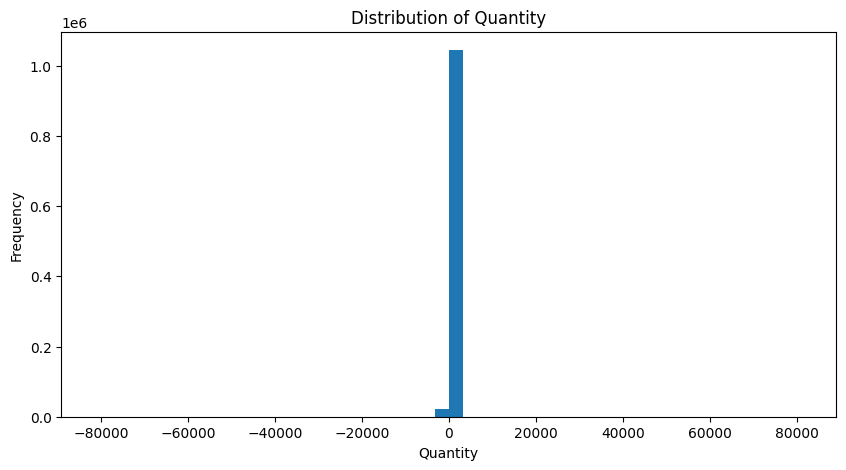

In [11]:
plt.figure(figsize=(10,5))

plt.hist(df["Quantity"], bins=50)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

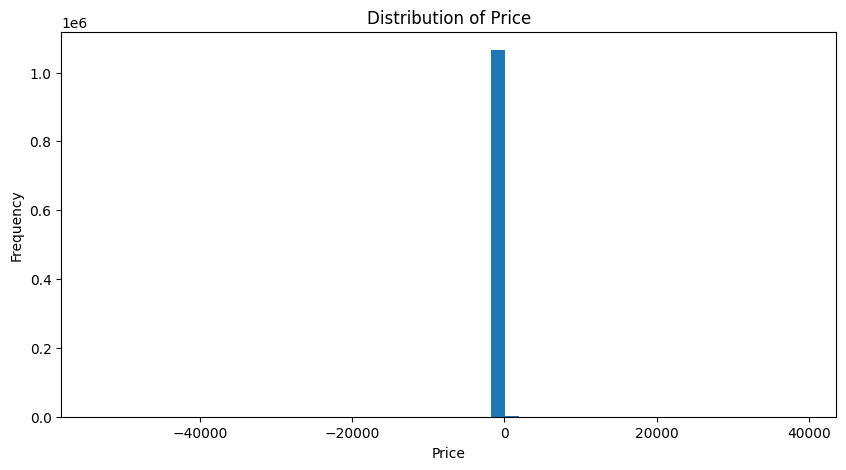

In [13]:
plt.figure(figsize=(10,5))

plt.hist(df["Price"], bins=50)

plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

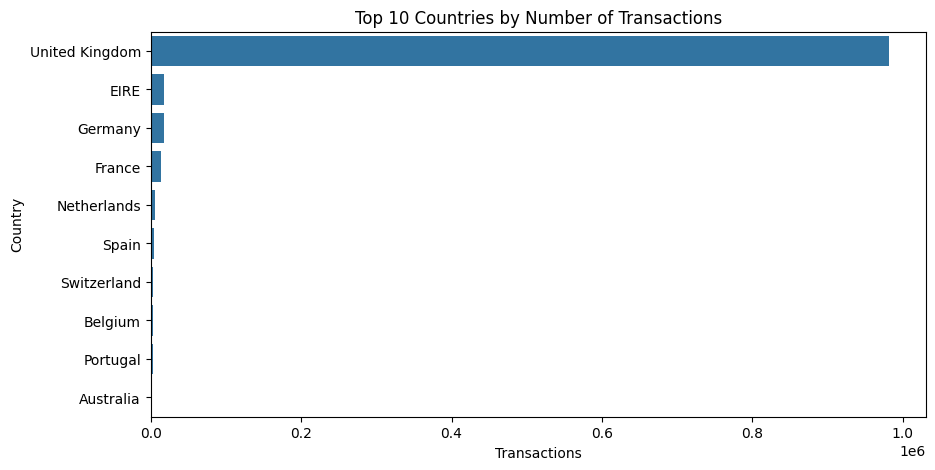

In [14]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Transactions")

plt.xlabel("Transactions")
plt.ylabel("Country")

plt.show()

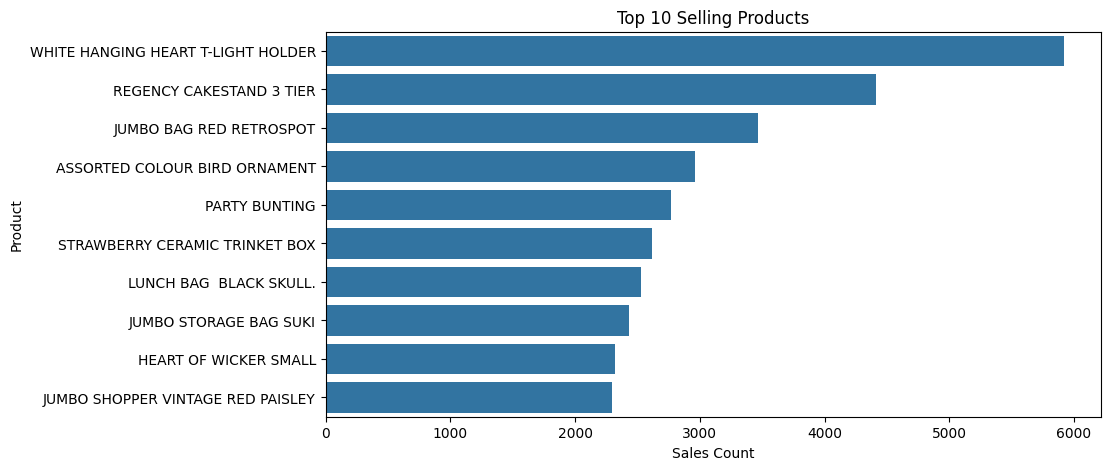

In [15]:
top_products = df["Description"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Selling Products")

plt.xlabel("Sales Count")
plt.ylabel("Product")

plt.show()

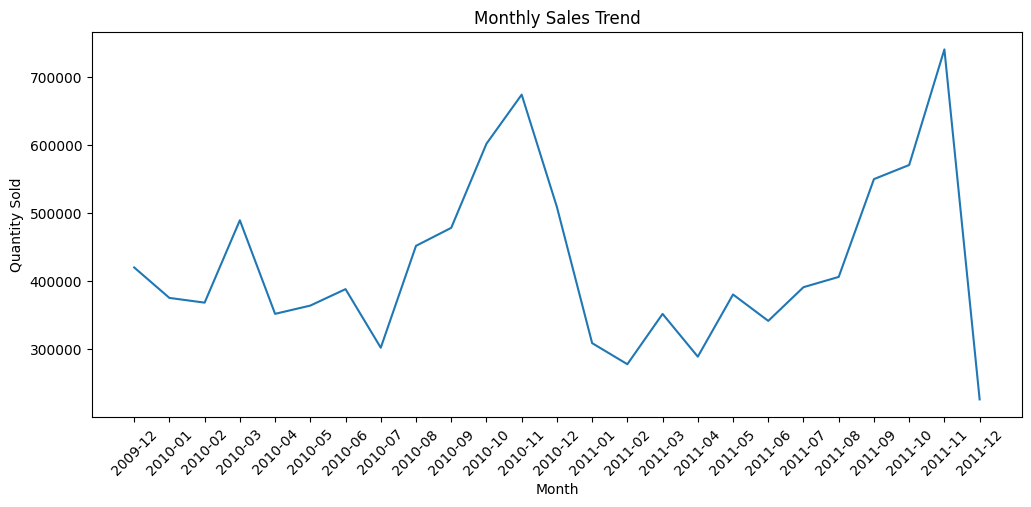

In [16]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

monthly_sales = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Quantity"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.show()

##4. Data Cleaning & RFM Analysis

In [18]:
df = df.dropna(subset=["Customer ID"])

In [19]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [20]:

df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

In [21]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

In [22]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

##RFM Table

In [23]:
import datetime as dt

snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "count",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,34,77556.46
12347.0,2,253,5633.32
12348.0,75,51,2019.40
12349.0,19,175,4428.69
12350.0,310,17,334.40


In [24]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,137.044743,3018.616737
std,209.338707,353.818629,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,21.000000,348.762500
50%,96.000000,53.000000,898.915000
75%,380.000000,142.000000,2307.090000
max,739.000000,12890.000000,608821.650000


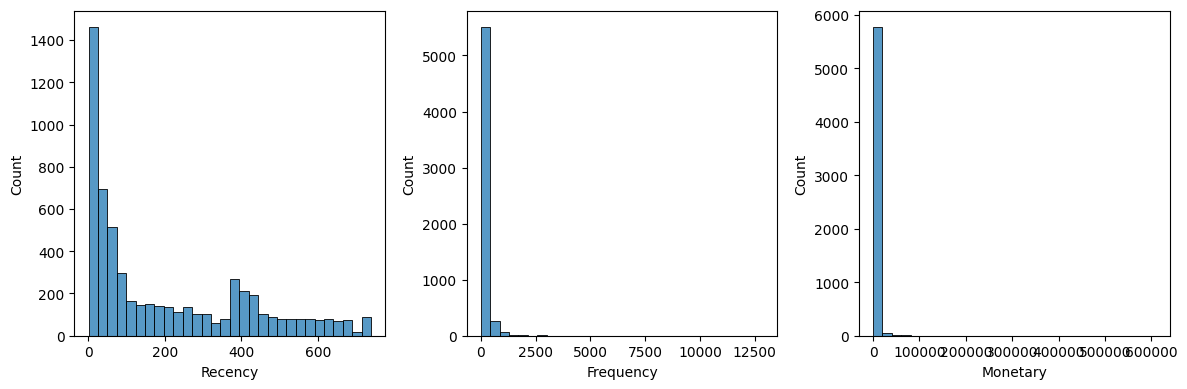

In [25]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(rfm["Recency"], bins=30)

plt.subplot(1,3,2)
sns.histplot(rfm["Frequency"], bins=30)

plt.subplot(1,3,3)
sns.histplot(rfm["Monetary"], bins=30)

plt.tight_layout()
plt.show()

##5. Feature Engineering & Pipeline

In [26]:
customer_features = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Quantity": "sum",
    "TotalAmount": "sum"
}).reset_index()

customer_features.columns = [
    "CustomerID",
    "TotalOrders",
    "TotalQuantity",
    "TotalSpending"
]

customer_features.head()

,CustomerID,TotalOrders,TotalQuantity,TotalSpending
0,12346.0,12,74285,77556.46
1,12347.0,8,3286,5633.32
2,12348.0,5,2714,2019.40
3,12349.0,4,1624,4428.69
4,12350.0,1,197,334.40


In [27]:
customer_features["AverageOrderValue"] = (
    customer_features["TotalSpending"] /
    customer_features["TotalOrders"]
)

customer_features.head()

,CustomerID,TotalOrders,TotalQuantity,TotalSpending,AverageOrderValue
0,12346.0,12,74285,77556.46,6463.038333
1,12347.0,8,3286,5633.32,704.165000
2,12348.0,5,2714,2019.40,403.880000
3,12349.0,4,1624,4428.69,1107.172500
4,12350.0,1,197,334.40,334.400000


In [28]:
rfm = rfm.reset_index()

feature_df = customer_features.merge(
    rfm,
    left_on="CustomerID",
    right_on="Customer ID",
    how="inner"
)

feature_df.head()

,CustomerID,TotalOrders,TotalQuantity,TotalSpending,AverageOrderValue,Customer ID,Recency,Frequency,Monetary
0,12346.0,12,74285,77556.46,6463.038333,12346.0,326,34,77556.46
1,12347.0,8,3286,5633.32,704.165000,12347.0,2,253,5633.32
2,12348.0,5,2714,2019.40,403.880000,12348.0,75,51,2019.40
3,12349.0,4,1624,4428.69,1107.172500,12349.0,19,175,4428.69
4,12350.0,1,197,334.40,334.400000,12350.0,310,17,334.40


In [29]:
features = feature_df[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "TotalOrders",
        "TotalQuantity",
        "TotalSpending",
        "AverageOrderValue"
    ]
]

features.head()

,Recency,Frequency,Monetary,TotalOrders,TotalQuantity,TotalSpending,AverageOrderValue
0,326,34,77556.46,12,74285,77556.46,6463.038333
1,2,253,5633.32,8,3286,5633.32,704.165000
2,75,51,2019.40,5,2714,2019.40,403.880000
3,19,175,4428.69,4,1624,4428.69,1107.172500
4,310,17,334.40,1,197,334.40,334.400000


In [30]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_features.head()

,Recency,Frequency,Monetary,TotalOrders,TotalQuantity,TotalSpending,AverageOrderValue
0,0.595584,-0.291261,5.058050,0.438998,8.085426,5.058050,4.997097
1,-0.952279,0.327753,0.177431,0.131502,0.163419,0.177431,0.257158
2,-0.603532,-0.243210,-0.067806,-0.099120,0.099596,-0.067806,0.010003
3,-0.871064,0.107282,0.095686,-0.175994,-0.022025,0.095686,0.588860
4,0.519146,-0.339312,-0.182148,-0.406616,-0.181249,-0.182148,-0.047184


In [31]:
print("Feature Matrix Shape:", scaled_features.shape)

scaled_features.describe()

Feature Matrix Shape: (5878, 7)


,Recency,Frequency,Monetary,TotalOrders,TotalQuantity,TotalSpending,AverageOrderValue
count,5.878000e+03,5.878000e+03,5.878000e+03,5.878000e+03,5.878000e+03,5.878000e+03,5.878000e+03
mean,-4.230860e-17,-2.296753e-17,9.670537e-18,-1.329699e-17,9.670537e-18,9.670537e-18,2.901161e-17
std,1.000085e+00,1.000085e+00,1.000085e+00,1.000085e+00,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.570564e-01,-3.845369e-01,-2.046396e-01,-4.066161e-01,-2.031182e-01,-2.046396e-01,-3.199892e-01
25%,-8.376226e-01,-3.280059e-01,-1.811732e-01,-4.066161e-01,-1.820298e-01,-1.811732e-01,-1.729050e-01
50%,-5.032078e-01,-2.375564e-01,-1.438405e-01,-2.528681e-01,-1.483887e-01,-1.438405e-01,-8.778508e-02
75%,8.535607e-01,1.400627e-02,-4.828337e-02,5.462788e-02,-4.969692e-02,-4.828337e-02,2.374011e-02
max,2.568631e+00,3.604683e+01,4.110908e+01,3.011236e+01,4.076785e+01,4.110908e+01,6.900967e+01


##6. Customer Segmentation

In [32]:
pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PCA1", "PCA2"]
)

pca_df.head()

,PCA1,PCA2
0,9.197857,6.852138
1,0.572888,-0.391200
2,-0.070661,-0.143814
3,0.240304,-0.028142
4,-0.619990,0.404956


In [33]:
inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(pca_df)
    inertia.append(model.inertia_)

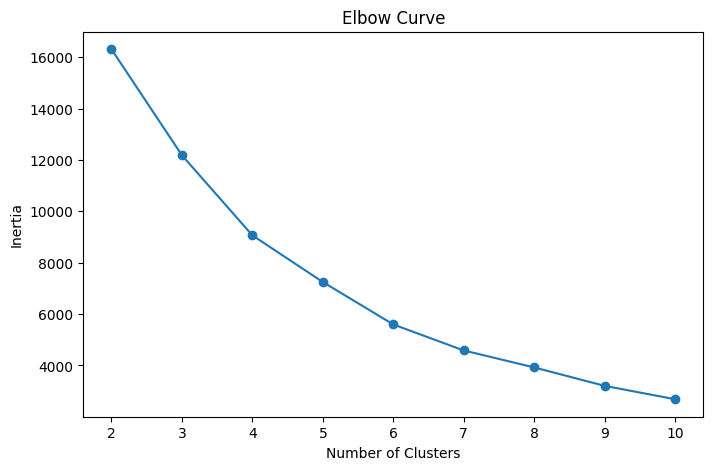

In [34]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [35]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(pca_df)

    score = silhouette_score(pca_df, labels)

    print(f"K = {k}  Score = {score:.3f}")

K = 2  Score = 0.955
K = 3  Score = 0.892
K = 4  Score = 0.600
K = 5  Score = 0.611
K = 6  Score = 0.502
K = 7  Score = 0.506
K = 8  Score = 0.516
K = 9  Score = 0.515
K = 10  Score = 0.512


In [36]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(pca_df)

pca_df["Cluster"] = clusters

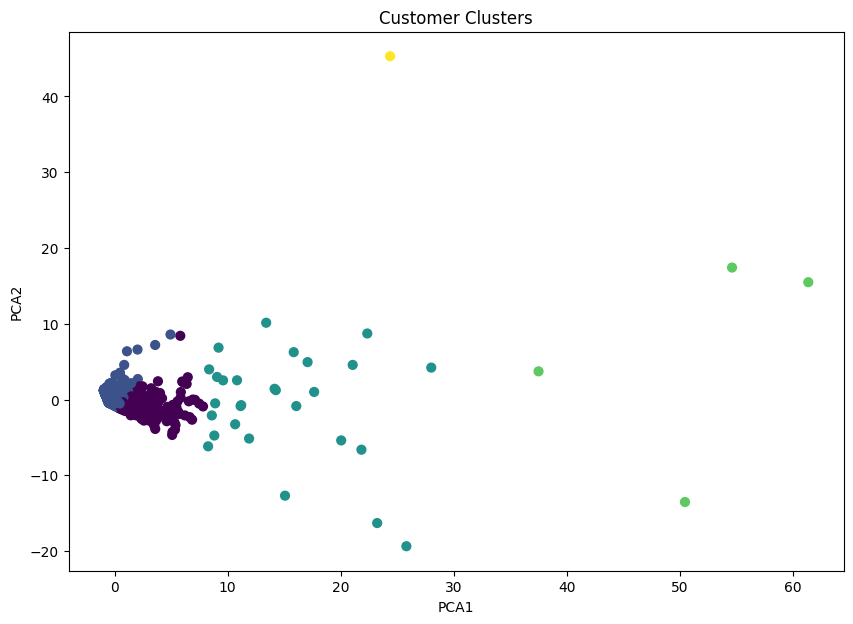

In [37]:
plt.figure(figsize=(10,7))

plt.scatter(
    pca_df["PCA1"],
    pca_df["PCA2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=40
)

plt.title("Customer Clusters")

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

In [38]:
feature_df["Cluster"] = clusters

cluster_summary = feature_df.groupby("Cluster")[
    ["Recency","Frequency","Monetary"]
].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,30.474432,507.065341,9889.720119
1,225.649874,71.013227,1209.589921
2,67.642857,2260.464286,94526.741500
3,3.500000,5050.000000,436835.792500
4,1.000000,3.000000,168472.500000


##Customer Cluster Profiles
| Cluster   | Business Persona                    |
| --------- | ----------------------------------- |
| Cluster 0 | Churn-Risk Inactive Customers       |
| Cluster 1 | Low-Value Occasional Buyers         |
| Cluster 2 | High-Value Loyal Customers          |
| Cluster 3 | VIP Elite Customers                 |
| Cluster 4 | Emerging / Low Engagement Customers |


In [39]:
feature_df["Cluster"].value_counts()

,count
Cluster,
1,5141
0,704
2,28
3,4
4,1


##7. Anomaly Detection

In [40]:
anomaly_data = df[["Quantity", "Price", "TotalAmount"]]
anomaly_data.head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [41]:
model = IsolationForest(
    contamination=0.01,
    random_state=42
)

model.fit(anomaly_data)

IsolationForest(contamination=0.01, random_state=42)

In [42]:
df["Anomaly"] = model.predict(anomaly_data)

df["Anomaly"].value_counts()

,count
Anomaly,
1,797493
-1,8056


In [43]:
anomalies = df[df["Anomaly"] == -1]
normal = df[df["Anomaly"] == 1]

print("Total Anomalies:", len(anomalies))

Total Anomalies: 8056


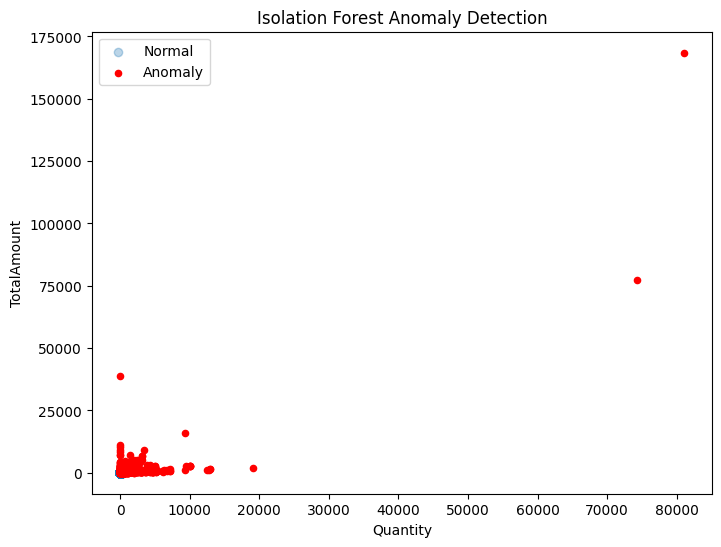

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    normal["Quantity"],
    normal["TotalAmount"],
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    anomalies["Quantity"],
    anomalies["TotalAmount"],
    color="red",
    label="Anomaly",
    s=20
)

plt.xlabel("Quantity")
plt.ylabel("TotalAmount")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()

plt.show()

In [45]:
print("Total Transactions:", len(df))
print("Normal Transactions:", (df["Anomaly"] == 1).sum())
print("Anomalous Transactions:", (df["Anomaly"] == -1).sum())

print("Anomaly %:", round((df["Anomaly"] == -1).mean() * 100, 2))

Total Transactions: 805549
Normal Transactions: 797493
Anomalous Transactions: 8056
Anomaly %: 1.0


##8. Time Series Forecasting

In [46]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

daily_sales = df.groupby(df["InvoiceDate"].dt.date)["TotalAmount"].sum()
daily_sales = daily_sales.reset_index()

daily_sales.columns = ["Date", "Sales"]

daily_sales.head()

,Date,Sales
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


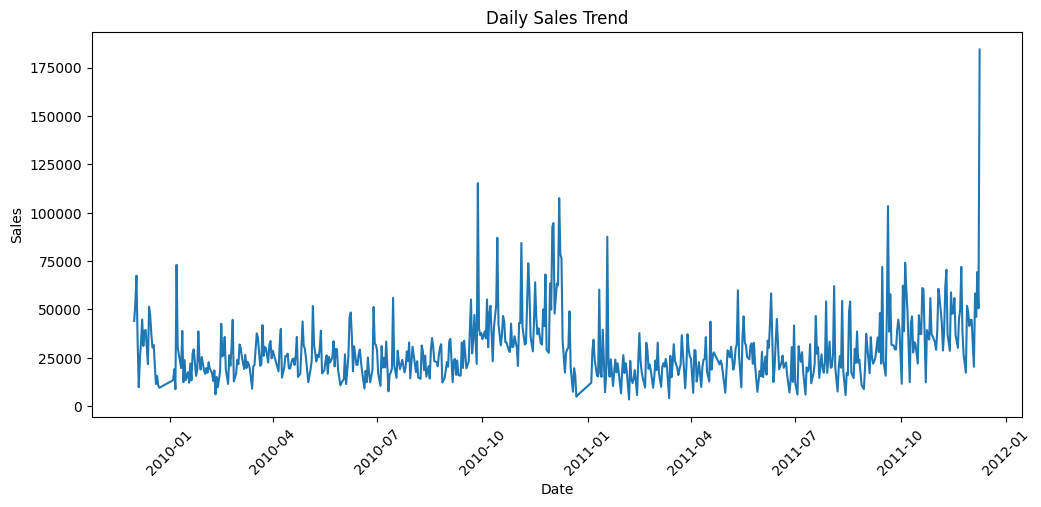

In [47]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales["Date"], daily_sales["Sales"])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

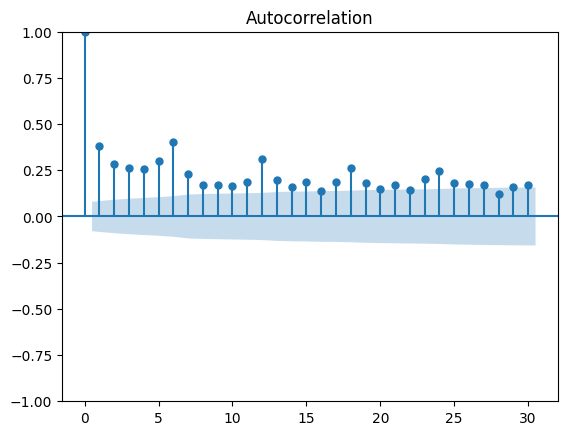

In [48]:
plot_acf(daily_sales["Sales"], lags=30)
plt.show()

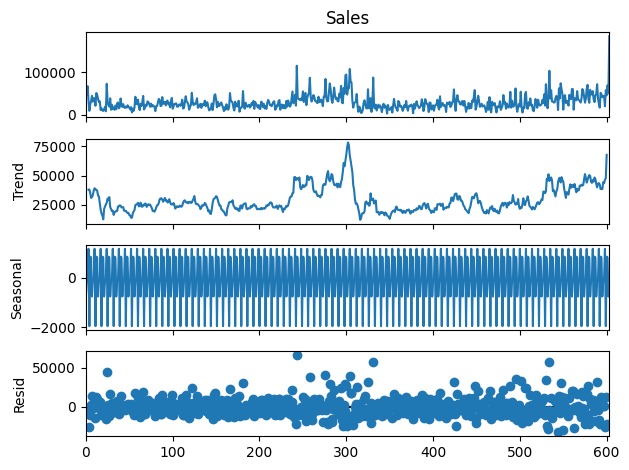

In [49]:
decomposition = seasonal_decompose(
    daily_sales["Sales"],
    model="additive",
    period=7
)

decomposition.plot()
plt.show()

In [50]:
model = ARIMA(daily_sales["Sales"], order=(5,1,0))
arima_model = model.fit()

forecast = arima_model.forecast(steps=30)
forecast

,predicted_mean
604,79592.333316
605,74642.103157
606,72744.143286
607,79390.753638
608,83905.983267
609,112877.183127
610,87701.310383
611,82787.451311
612,82323.502073
613,84880.543607


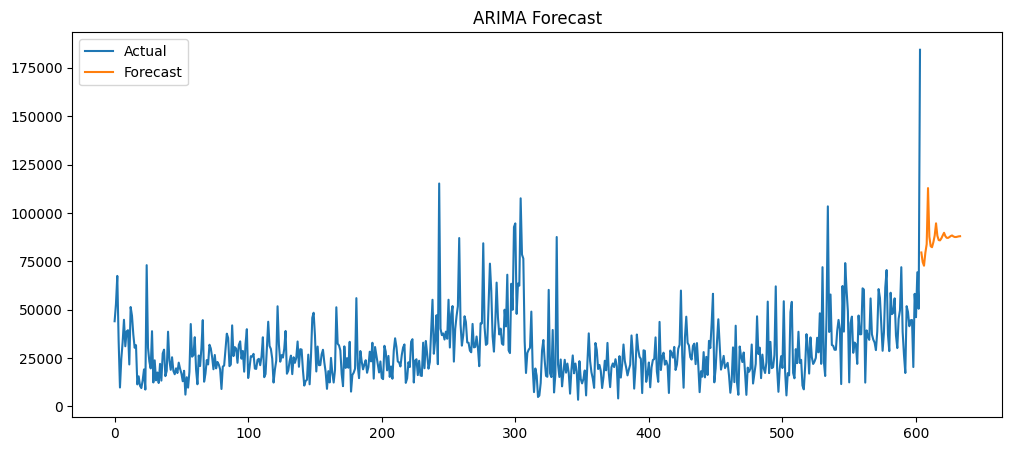

In [51]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales["Sales"], label="Actual")
plt.plot(range(len(daily_sales), len(daily_sales)+30),
         forecast,
         label="Forecast")

plt.title("ARIMA Forecast")
plt.legend()

plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


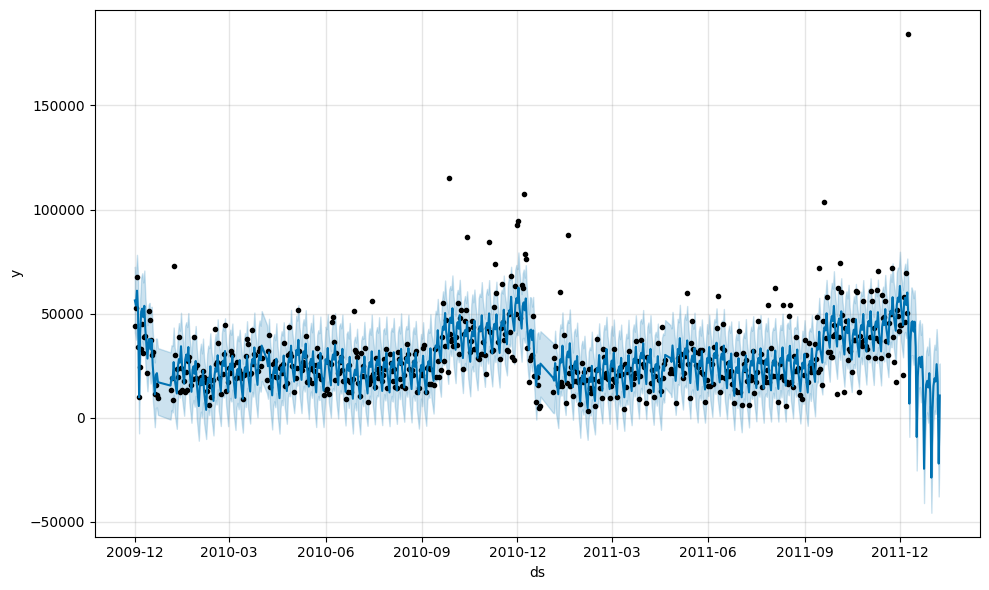

In [52]:
prophet_df = daily_sales.rename(columns={
    "Date": "ds",
    "Sales": "y"
})

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)
plt.show()

In [53]:
actual = prophet_df["y"][-30:]
predicted = forecast["yhat"][-30:]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = mean_absolute_percentage_error(actual, predicted)

print("RMSE:", rmse)
print("MAPE:", mape)

RMSE: 48537.259660164615
MAPE: 0.616193068564671


# 9. Business Strategy & Insights

## Customer Cluster Profiles

- **High-Value Loyal Customers:** High frequency and high monetary value customers who generate most of the revenue. Focus on retention and loyalty programs.

- **Regular Customers:** Moderate spending and frequency. Can be upgraded through targeted promotions and personalized recommendations.

- **Occasional Buyers:** Low frequency and low spending customers. Require engagement campaigns and discounts to increase activity.

- **Churn-Risk Customers:** High recency but low frequency. These customers are inactive and need re-engagement strategies.

- **Emerging Customers:** New customers with potential growth. Should be nurtured to become long-term loyal customers.

---

## Strategic Recommendations

### 1. Customer Retention Strategy
Implement loyalty programs, exclusive discounts, and personalized marketing for high-value customers to maximize lifetime value.

### 2. Inventory Optimization
Use demand forecasting results to improve stock planning, reduce overstocking, and prevent stock shortages.

### 3. Customer Re-Engagement
Target churn-risk customers with special offers, reminders, and time-limited promotions to improve retention rates.

---

## Business Impact

This system enables data-driven decision-making by integrating customer segmentation, anomaly detection, and demand forecasting. It improves marketing efficiency, enhances inventory management, and increases overall business profitability.

# 10. Conclusion

This project presents an end-to-end machine learning solution for omnichannel retail analytics, integrating customer behavior analysis, segmentation, anomaly detection, and demand forecasting.

The system successfully processes raw transactional data, performs RFM-based customer segmentation, and applies machine learning techniques such as K-Means clustering and Isolation Forest for behavioral insights.

Time series forecasting models like ARIMA and Prophet are used to predict future sales trends, enabling better inventory planning and demand management.

## Key Outcomes

- Developed meaningful customer segments using RFM and clustering techniques.
- Identified high-value, regular, and churn-risk customers for targeted business strategies.
- Detected anomalous transactions to improve data quality and fraud detection.
- Forecasted future demand using statistical and ML-based time series models.
- Generated actionable business insights for marketing and supply chain optimization.

## Final Impact

This system helps businesses make data-driven decisions by combining customer analytics with predictive modeling, ultimately improving revenue, customer retention, and operational efficiency.